# Healthcare Insurance: Analysis and Visualisation

## Objectives

- Describe the distribution of insurance charges.
- Investigate smoking status and BMI.
- Analyse age, dependants, recorded sex and region.
- Examine correlations between available variables.
- Build and evaluate a simple prediction model.
- Communicate findings, limitations and recommendations.

## Input

- `data/processed/insurance_clean.csv`

## Load and Verify the Processed Data

Before beginning the analysis, the processed dataset was checked to ensure that it was suitable for use. The checks confirmed that:

- the expected columns were present;
- there were no missing values;
- duplicate rows had been removed;
- numerical values were within reasonable ranges;
- categorical values were consistent;
- the engineered features had been created successfully.

The cleaned dataset is now loaded from the `data/processed` folder. A final check of its shape, column names and first few rows is performed below before visualisation and analysis begin.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    palette="colorblind"
)

currency_formatter = FuncFormatter(
    lambda value, position: f"${value:,.0f}"
)

project_root = Path.cwd()

if project_root.name == "jupyter_notebooks":
    project_root = project_root.parent

processed_data_path = (
    project_root
    / "data"
    / "processed"
    / "insurance_clean.csv"
)

insurance = pd.read_csv(
    processed_data_path
)

print(f"Rows: {len(insurance):,}")
print(f"Columns: {insurance.shape[1]}")

insurance.head()

Rows: 1,337
Columns: 9


,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,18-24,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,18-24,Obesity
2,28,male,33.000,3,no,southeast,4449.46200,25-34,Obesity
3,33,male,22.705,0,no,northwest,21984.47061,25-34,Healthy weight
4,32,male,28.880,0,no,northwest,3866.85520,25-34,Overweight


In [2]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1337 non-null   int64  
 1   sex           1337 non-null   object 
 2   bmi           1337 non-null   float64
 3   children      1337 non-null   int64  
 4   smoker        1337 non-null   object 
 5   region        1337 non-null   object 
 6   charges       1337 non-null   float64
 7   age_group     1337 non-null   object 
 8   bmi_category  1337 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 94.1+ KB


In [3]:
insurance.isna().sum()

age             0
sex             0
bmi             0
children        0
smoker          0
region          0
charges         0
age_group       0
bmi_category    0
dtype: int64

In [4]:
insurance.duplicated().sum()

0

The processed dataset loaded successfully. The final checks found no missing values or duplicate rows, so the data is ready for exploratory analysis and visualisation.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import StrMethodFormatter

insurance_df = pd.read_csv(
    "../data/processed/insurance_clean.csv"
)

sns.set_theme(
    style="whitegrid",
    palette="colorblind"
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"

insurance_df.head()

,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,18-24,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,18-24,Obesity
2,28,male,33.000,3,no,southeast,4449.46200,25-34,Obesity
3,33,male,22.705,0,no,northwest,21984.47061,25-34,Healthy weight
4,32,male,28.880,0,no,northwest,3866.85520,25-34,Overweight


## Distribution of Insurance Charges

This histogram shows how frequently different insurance charge values occur. It helps identify the typical range of charges, the shape of the distribution and any unusually high values.

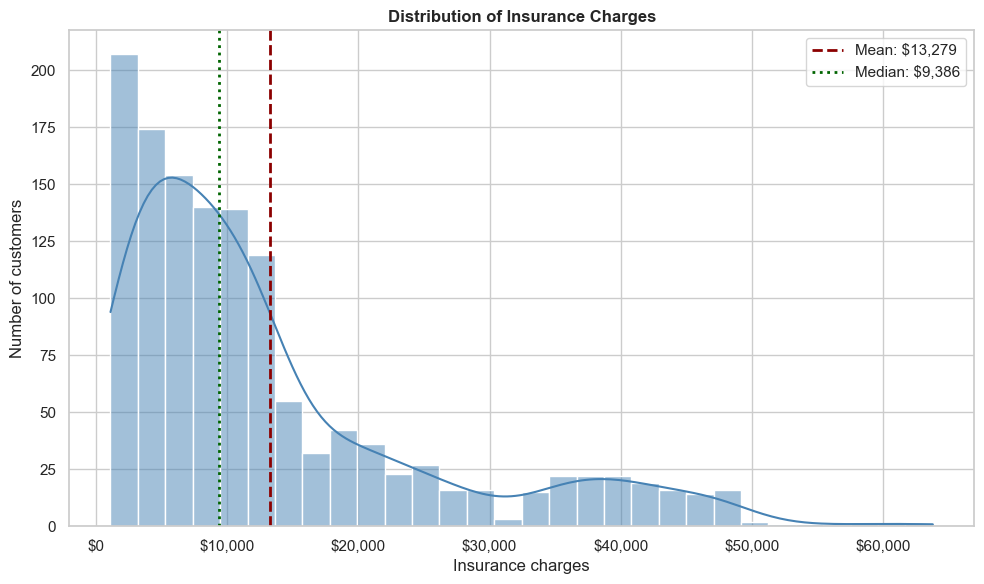

In [ ]:
mean_charge = insurance_df["charges"].mean()
median_charge = insurance_df["charges"].median()

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=insurance_df,
    x="charges",
    bins=30,
    kde=True,
    color="steelblue",
    ax=ax
)

ax.axvline(
    mean_charge,
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"Mean: ${mean_charge:,.0f}"
)

ax.axvline(
    median_charge,
    color="darkgreen",
    linestyle=":",
    linewidth=2,
    label=f"Median: ${median_charge:,.0f}"
)

ax.set_title("Distribution of Insurance Charges")
ax.set_xlabel("Insurance charges")
ax.set_ylabel("Number of customers")
ax.xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
ax.legend()

plt.tight_layout()
plt.show()

### Interpretation

- The distribution is strongly right-skewed (positively skewed), with a long tail extending toward higher insurance charges
- Most recorded charges fall between approximately $2,000 and $15,000, with the highest concentration of customers paying under $10,000
- The mean charge ($13,270) is higher than the median charge ($9,386). This suggests that a relatively small number of customers with very high insurance charges are pulling the average upward
- A smaller number of customers have substantially higher charges, with some charges exceeding $50,000–$60,000, although these cases are much less common than lower-charge observations
- For the imaginary insurance business, this could indicate that a relatively small group of customers accounts for a disproportionately large share of total insurance costs. The business may wish to investigate which customer characteristics (such as smoking status, age, BMI, or medical conditions) are associated with these higher charges to better understand cost drivers and manage financial risk
- This chart only describes the distribution of insurance charges. It does not explain why some customers have higher charges, and causal conclusions cannot be drawn from this observational dataset alone

## Insurance Charges by Smoking Status

This box plot compares the distribution of insurance charges for smokers and non-smokers. The line inside each box represents the median, while the box shows the middle 50% of the values.

In [9]:
smoking_summary = (
    insurance_df.groupby("smoker")["charges"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

smoking_summary

,count,mean,median,min,max
smoker,,,,,
no,1063,8440.66,7345.73,1121.87,36910.61
yes,274,32050.23,34456.35,12829.46,63770.43


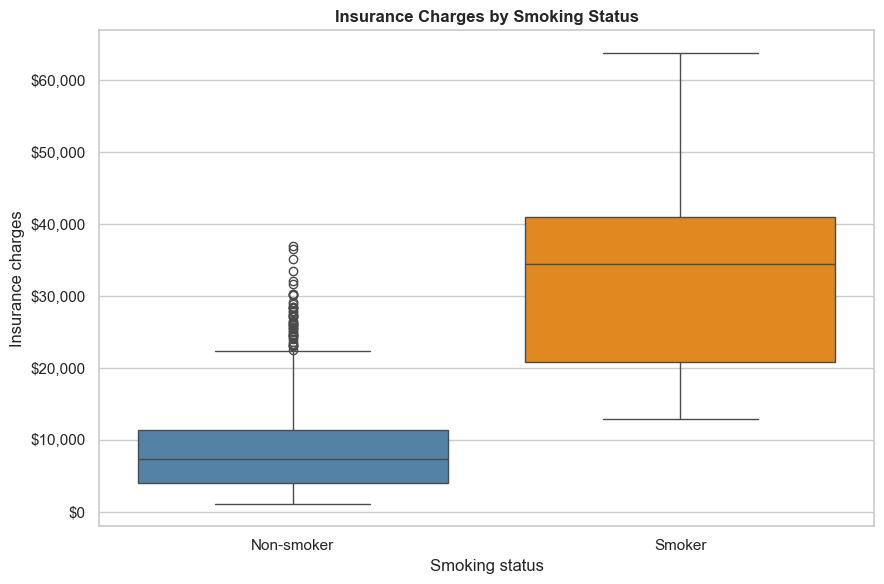

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(
    data=insurance_df,
    x="smoker",
    y="charges",
    order=["no", "yes"],
    hue="smoker",
    hue_order=["no", "yes"],
    palette={
        "no": "steelblue",
        "yes": "darkorange"
    },
    legend=False,
    ax=ax
)

ax.set_title("Insurance Charges by Smoking Status")
ax.set_xlabel("Smoking status")
ax.set_ylabel("Insurance charges")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Non-smoker", "Smoker"])
ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))

plt.tight_layout()
plt.show()

### Interpretation

- The box plot shows that customers recorded as smokers have the higher typical insurance charges than non-smokers
- The median charge for smokers is approximately $34,456, compared with approximately $7,346 for non-smokers, indicating that smokers typically incur much higher insurance costs
- The smoker group also has the greater spread of charges, as shown by the wider box and longer whiskers. This indicates that insurance charges for smokers vary more widely than those for non-smokers
- The non-smoker group has a smaller spread of charges, although there are several high-cost outliers, showing that some non-smokers also experience unusually high insurance charges
- For the imaginary insurance business, smoking status may be a useful predictor when estimating future healthcare costs and identifying customers associated with higher insurance claims, as smokers generally have substantially higher and more variable charges
- However, this analysis does not prove that smoking caused the higher charges. Other factors, including age, BMI, medical history, and differences in the characteristics of the smoker and non-smoker groups, may also contribute to the observed differences in insurance charges

In [11]:
insurance_df["bmi_category"].value_counts(dropna=False)

bmi_category
Obesity           706
Overweight        386
Healthy weight    225
Underweight        20
Name: count, dtype: int64

## Charges by BMI Category and Smoking Status

This chart compares typical insurance charges across BMI categories while separating smokers and non-smokers. The median is used because the charge distribution contains high values that could strongly affect the mean.

In [12]:
bmi_order = [
    "Underweight",
    "Healthy weight",
    "Overweight",
    "Obesity"
]

bmi_smoking_summary = (
    insurance_df.groupby(
        ["bmi_category", "smoker"],
        observed=True
    )["charges"]
    .agg(["count", "median", "mean"])
    .round(2)
)

bmi_smoking_summary

count    median      mean
bmi_category   smoker                           
Healthy weight no        175   6593.51   7685.66
               yes        50  19479.90  19942.22
Obesity        no        561   8083.92   8855.53
               yes       145  40904.20  41557.99
Overweight     no        312   7063.92   8257.96
               yes        74  21215.43  22495.87
Underweight    no         15   3732.63   5532.99
               yes         5  15006.58  18809.82

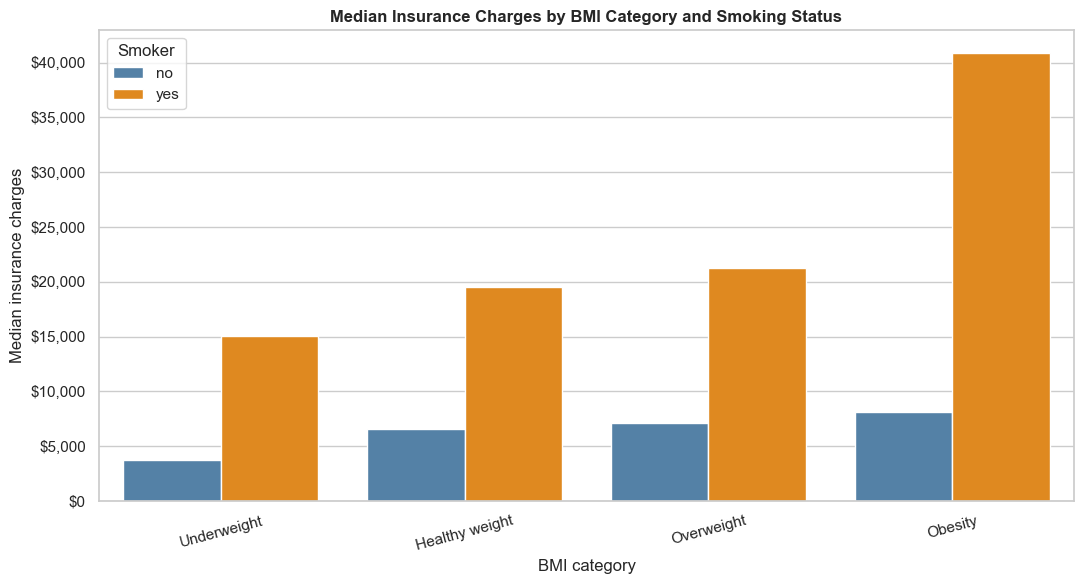

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=insurance_df,
    x="bmi_category",
    y="charges",
    hue="smoker",
    order=bmi_order,
    hue_order=["no", "yes"],
    estimator=np.median,
    errorbar=None,
    palette={
        "no": "steelblue",
        "yes": "darkorange"
    },
    ax=ax
)

ax.set_title("Median Insurance Charges by BMI Category and Smoking Status")
ax.set_xlabel("BMI category")
ax.set_ylabel("Median insurance charges")
ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
ax.legend(title="Smoker")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Interpretation

- The chart shows that smoking status is associated with substantially higher median insurance charges across every BMI category. While median charges increase slightly with BMI for non-smokers, the increase is much larger for smokers, particularly in the obesity category
- The group with the highest median charge is customers with obesity who smoke, with a median insurance charge of approximately $41,000
- The group with the lowest median charge is underweight non-smokers, with a median insurance charge of approximately $3,500–$4,000
- For the imaginary insurance business, considering BMI and smoking status together may provide more useful information for estimating healthcare costs than examining either characteristic alone. The chart suggests that smoking has a strong association with higher charges, and this effect appears to be even greater among customers with obesity
- Some BMI categories, particularly the underweight group, may contain considerably fewer customers than others, making their median estimates less reliable. In addition, BMI is only a simplified measure of health, and this observational comparison cannot establish that either BMI or smoking caused the recorded insurance charges. Other factors, such as age, sex, medical conditions, and lifestyle, may also influence the observed differences

## Relationship Between Age and Insurance Charges

This scatter plot examines the relationship between customer age and insurance charges. Colour is used to show whether each customer was recorded as a smoker or non-smoker.

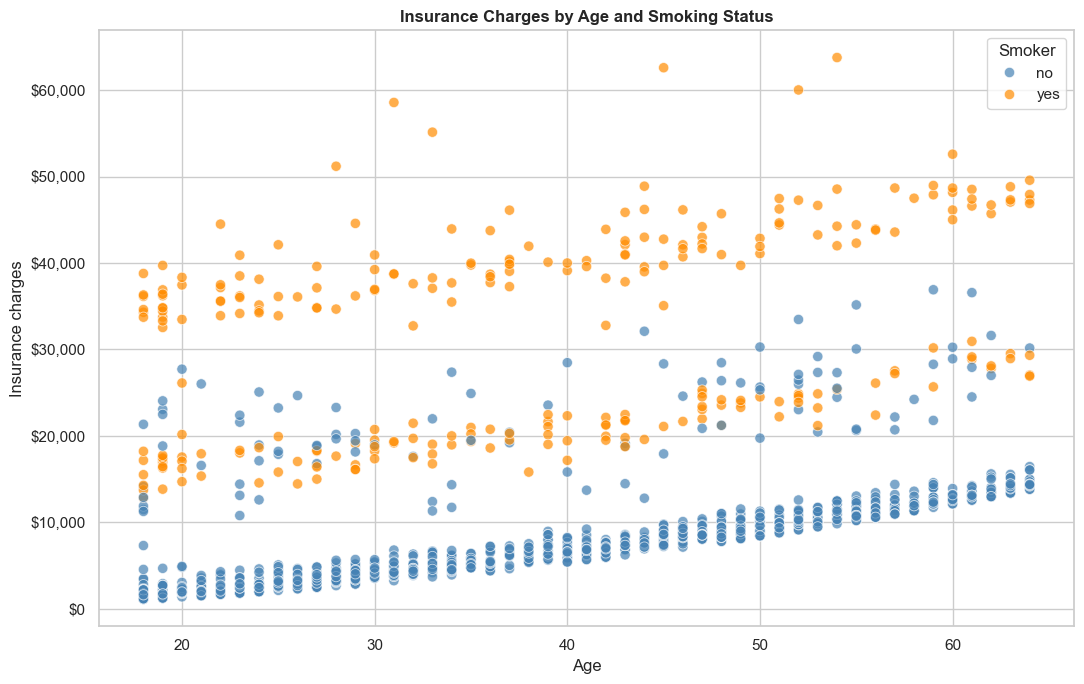

In [14]:
fig, ax = plt.subplots(figsize=(11, 7))

sns.scatterplot(
    data=insurance_df,
    x="age",
    y="charges",
    hue="smoker",
    hue_order=["no", "yes"],
    palette={
        "no": "steelblue",
        "yes": "darkorange"
    },
    alpha=0.70,
    s=55,
    ax=ax
)

ax.set_title("Insurance Charges by Age and Smoking Status")
ax.set_xlabel("Age")
ax.set_ylabel("Insurance charges")
ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
ax.legend(title="Smoker")

plt.tight_layout()
plt.show()

In [15]:
age_charge_correlation = insurance_df["age"].corr(
    insurance_df["charges"]
)

print(
    "Correlation between age and charges:",
    round(age_charge_correlation, 3)
)

Correlation between age and charges: 0.298


### Interpretation

- The scatter plot shows a weak positive relationship between age and insurance charges. This is supported by the correlation coefficient of 0.298, indicating that insurance charges generally increase as age increases, although the relationship is not particularly strong
- Customers recorded as smokers generally appear in the higher charge ranges, with many smoker observations above $30,000, whereas most non-smokers have considerably lower charges
- The highest recorded charges appear among older smokers, with several observations exceeding $60,000. This suggests that high insurance charges are more common among customers who are both older and smokers
- For the imaginary insurance business, age and smoking status together may help identify broad cost patterns and support financial forecasting. Smoking appears to have a particularly strong association with higher charges, while age is associated with a gradual increase in charges
- The points show considerable variation, meaning that age alone does not explain a customer's insurance charges. Customers of similar ages can have very different costs, particularly among smokers. As this is an observational dataset, it does not include all factors that influence insurance charges, such as medical diagnoses, treatment history, or insurance plan type. Therefore, the observed relationships should not be interpreted as causal

## Average Insurance Charges by Region

This chart compares mean insurance charges across the four recorded regions. The customer count and median are also calculated to provide context for each regional average.

In [16]:
region_summary = (
    insurance_df.groupby("region")["charges"]
    .agg(
        customer_count="count",
        average_charge="mean",
        median_charge="median"
    )
    .sort_values("average_charge", ascending=False)
    .round(2)
    .reset_index()
)

region_summary

,region,customer_count,average_charge,median_charge
0,southeast,364,14735.41,9294.13
1,northeast,324,13406.38,10057.65
2,northwest,324,12450.84,8976.98
3,southwest,325,12346.94,8798.59


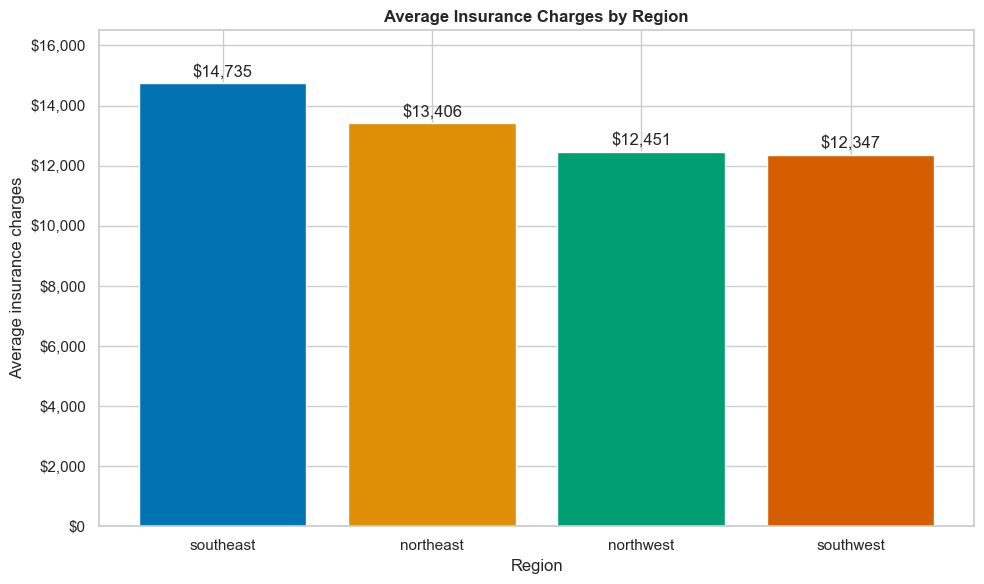

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = sns.color_palette(
    "colorblind",
    n_colors=len(region_summary)
)

bars = ax.bar(
    region_summary["region"],
    region_summary["average_charge"],
    color=colors
)

ax.set_title("Average Insurance Charges by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Average insurance charges")

ax.yaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

ax.bar_label(
    bars,
    labels=[
        f"${value:,.0f}"
        for value in region_summary["average_charge"]
    ],
    padding=3
)

# Give the labels some extra room
ax.set_ylim(
    0,
    region_summary["average_charge"].max() * 1.12
)

plt.tight_layout()
plt.show()

### Interpretation

- The southeast has the highest average insurance charge, at approximately $14,735
- The southwest has the lowest average charge, while the northwest has a similarly low average
- The regional differences may help the imaginary insurance business identify where average customer costs are higher and support regional budgeting
- However, region alone may not explain these differences. The regions could contain different proportions of smokers, age groups or BMI categories. High individual charges can also affect the mean
- Because this is observational data, the chart does not prove that living in a particular region causes higher insurance charges

## Charges by Recorded Sex and Number of Dependants

This chart compares average insurance charges by the number of recorded dependants, with the results separated by the sex categories provided in the dataset.

In [20]:
sex_dependants_summary = (
    insurance_df.groupby(["children", "sex"])["charges"]
    .agg(
        customer_count="count",
        average_charge="mean",
        median_charge="median"
    )
    .round(2)
)

sex_dependants_summary

customer_count  average_charge  median_charge
children sex                                                  
0        female             289        11905.71        9541.70
         male               284        12872.11       10220.46
1        female             158        12161.36        8232.87
         male               166        13273.52        8734.35
2        female             119        13941.32       10107.22
         male               121        16187.10        8603.82
3        female              77        13865.61       11085.59
         male                80        16789.17       10414.98
4        female              11        13937.67       11033.66
         male                14        13782.28       11128.49
5        female               8         9854.01        8781.31
         male                10         7931.66        6732.85

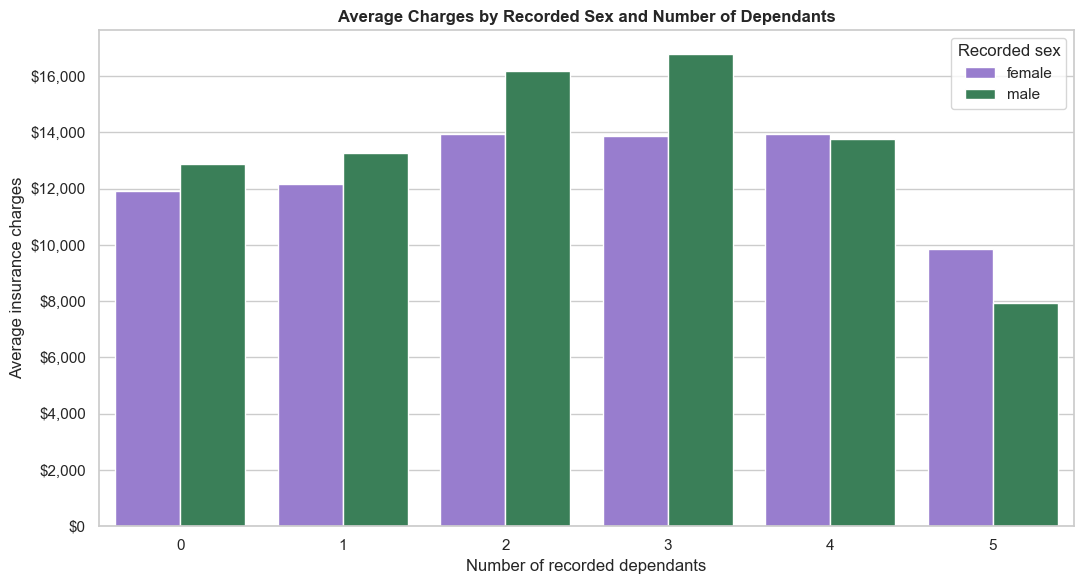

In [21]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=insurance_df,
    x="children",
    y="charges",
    hue="sex",
    hue_order=["female", "male"],
    estimator=np.mean,
    errorbar=None,
    palette={
        "female": "mediumpurple",
        "male": "seagreen"
    },
    ax=ax
)

ax.set_title("Average Charges by Recorded Sex and Number of Dependants")
ax.set_xlabel("Number of recorded dependants")
ax.set_ylabel("Average insurance charges")
ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
ax.legend(title="Recorded sex")

plt.tight_layout()
plt.show()

### Interpretation

- Average charges do not follow a consistent pattern as the number of recorded dependants changes. They generally rise from zero to three dependants, remain similar at four, and then fall noticeably at five
- The highest average charge is visible for males with three dependants, at approximately $16,700
- The lowest average charge is visible for males with five dependants, at approximately $7,900
- Differences between the recorded sex categories are moderate and inconsistent. Males have higher average charges for zero to three dependants, while females have slightly higher averages for four and five dependants
- For the imaginary business, the number of dependants may help describe broad customer groups, but recorded sex is a protected personal characteristic and should be handled carefully rather than used to support unfair pricing or treatment

## Correlation Between Dataset Features

The heatmap shows the strength and direction of linear relationships between numerical and encoded features.

Correlation values range from `-1` to `1`:

- values close to `1` indicate a strong positive relationship;
- values close to `-1` indicate a strong negative relationship;
- values close to `0` indicate a weak linear relationship.

The encoded category values are created only to support this correlation analysis.

In [22]:
correlation_data = insurance_df[
    ["age", "bmi", "children", "charges"]
].copy()

correlation_data["smoker_yes"] = insurance_df["smoker"].map({
    "no": 0,
    "yes": 1
})

correlation_data["sex_male"] = insurance_df["sex"].map({
    "female": 0,
    "male": 1
})

region_columns = pd.get_dummies(
    insurance_df["region"],
    prefix="region",
    dtype=int
)

correlation_data = pd.concat(
    [correlation_data, region_columns],
    axis=1
)

correlation_matrix = correlation_data.corr()

correlation_matrix.round(2)

,age,bmi,children,charges,smoker_yes,sex_male,region_northeast,region_northwest,region_southeast,region_southwest
age,1.00,0.11,0.04,0.30,-0.03,-0.02,0.00,0.00,-0.01,0.01
bmi,0.11,1.00,0.01,0.20,0.00,0.05,-0.14,-0.14,0.27,-0.01
children,0.04,0.01,1.00,0.07,0.01,0.02,-0.02,0.03,-0.02,0.02
charges,0.30,0.20,0.07,1.00,0.79,0.06,0.01,-0.04,0.07,-0.04
smoker_yes,-0.03,0.00,0.01,0.79,1.00,0.08,0.00,-0.04,0.07,-0.04
sex_male,-0.02,0.05,0.02,0.06,0.08,1.00,-0.00,-0.01,0.02,-0.00
region_northeast,0.00,-0.14,-0.02,0.01,0.00,-0.00,1.00,-0.32,-0.35,-0.32
region_northwest,0.00,-0.14,0.03,-0.04,-0.04,-0.01,-0.32,1.00,-0.35,-0.32
region_southeast,-0.01,0.27,-0.02,0.07,0.07,0.02,-0.35,-0.35,1.00,-0.35
region_southwest,0.01,-0.01,0.02,-0.04,-0.04,-0.00,-0.32,-0.32,-0.35,1.00


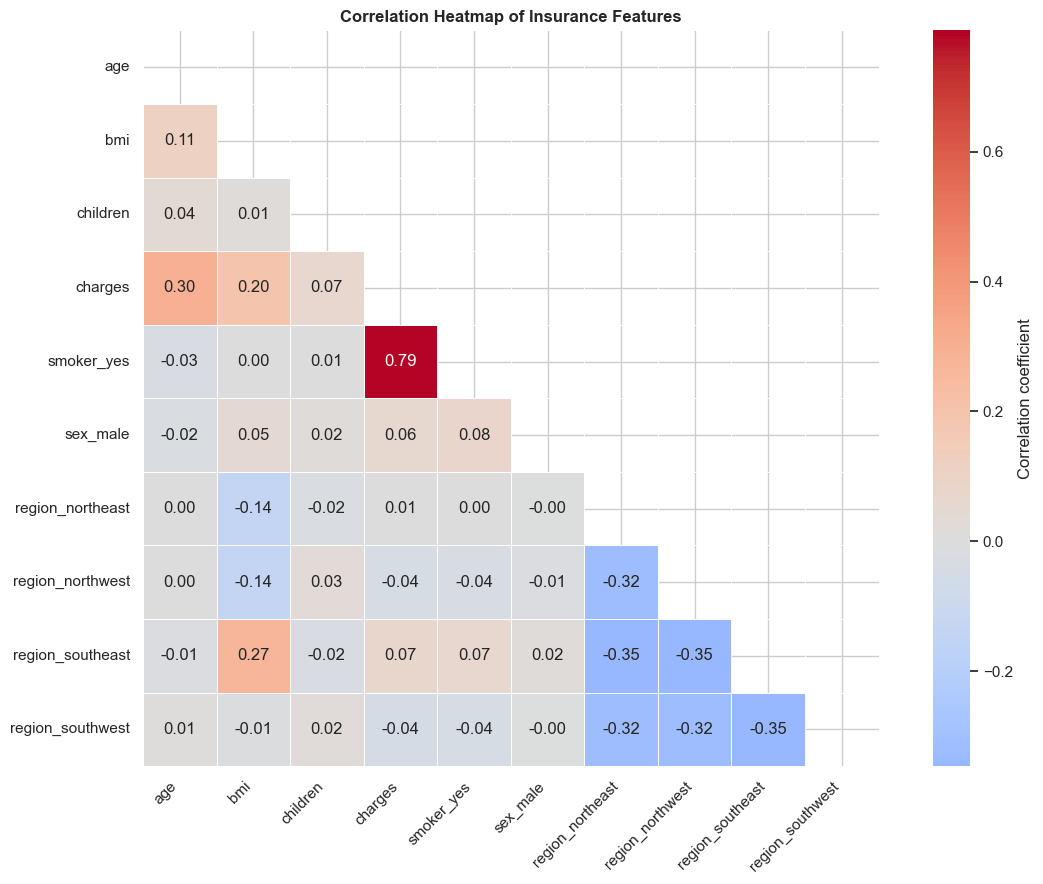

In [23]:
mask = np.triu(
    np.ones_like(correlation_matrix, dtype=bool)
)

fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={
        "label": "Correlation coefficient"
    },
    ax=ax
)

ax.set_title("Correlation Heatmap of Insurance Features")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:
charge_correlations = (
    correlation_matrix["charges"]
    .drop("charges")
    .sort_values(key=abs, ascending=False)
)

charge_correlations

smoker_yes          0.787234
age                 0.298308
bmi                 0.198401
region_southeast    0.073578
children            0.067389
sex_male            0.058044
region_southwest   -0.043637
region_northwest   -0.038695
region_northeast    0.005945
Name: charges, dtype: float64

### Interpretation

- The feature with the strongest positive correlation with insurance charges is smoker_yes, with a correlation of approximately 0.79. This indicates a strong positive relationship, meaning customers recorded as smokers tend to have substantially higher insurance charges than non-smokers
- Age has a weak positive relationship with insurance charges (r ≈ 0.30), while BMI also has a weak positive relationship (r ≈ 0.20). This suggests that charges tend to increase as age and BMI increase, although these relationships are much weaker than the relationship with smoking status
- The feature with the weakest relationship with insurance charges is region_northeast (r ≈ 0.01), indicating virtually no linear association. Similarly, sex (sex_male, r ≈ 0.06), number of children (r ≈ 0.07), and the regional variables have only very weak relationships with insurance charges
- For the imaginary insurance business, smoking status appears to be the most informative predictor of insurance charges, while age and BMI may provide additional predictive value. Features with very weak correlations, such as region and recorded sex, are likely to contribute relatively little when considered on their own
- Correlation measures association, not causation. It captures only linear relationships and does not account for interactions between variables. The encoded categorical variables (such as smoker, sex, and region) are simplified numerical representations, and other unmeasured factors may also influence insurance charges. Therefore, these correlations should be interpreted as indicators of association rather than evidence of cause and effect